In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import save_image, make_grid
from torchvision.transforms import ToPILImage

# Import from text2img.py - the refactored modular functions
from text2img import load_models, generate_from_prompts

# Import other custom modules
from src.dataloader import FashionTextImageDataset, fm_transform
from src.evaluate import save_real_fake_grid

print("All modules imported successfully!")


All modules imported successfully!


In [6]:
# Load models using the function from text2img.py
generator, clip_model, device = load_models(model_path="./models/generator_190.pth")

print(f"Using device: {device}")
print("Generator and CLIP models loaded successfully!")

# Model hyperparameters (for reference)
latent_dim = 150
embed_dim = 512
batch_size = 8


Using device: cuda
Generator and CLIP models loaded successfully!


Dataset loaded with 10000 samples
Showing 8 random samples from the dataset:
Dataset has 10000 total samples


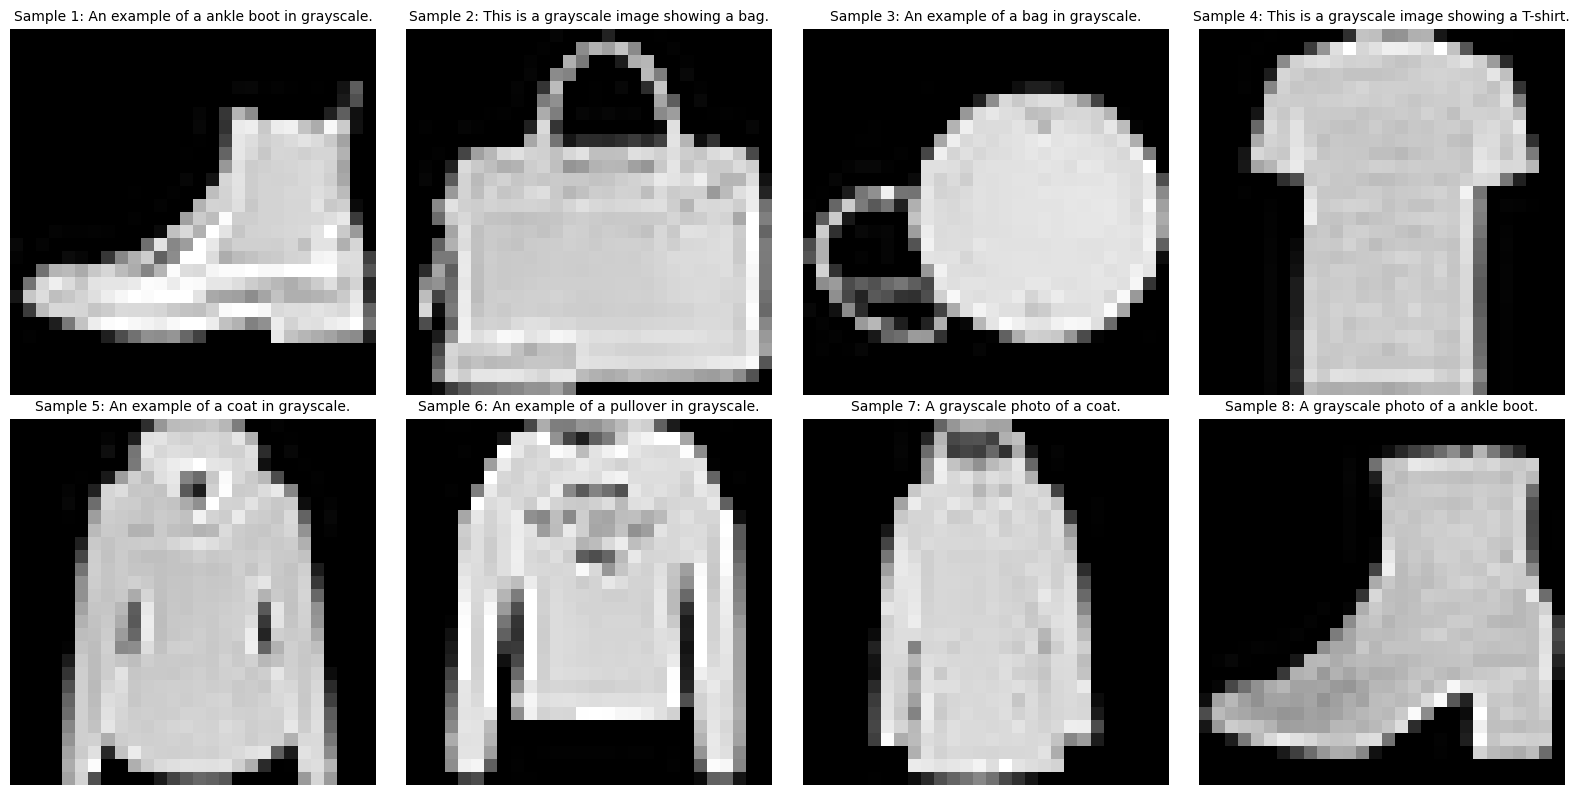

In [ ]:
# Load test dataset for demonstration
parquet_path = "./data/fashion_CLIP_test_caps.parquet"
img_dir = "./data"

# Create dataset with transform for proper tensor conversion
dataset = FashionTextImageDataset(
    root=img_dir,
    parquet_path=parquet_path,
    train=False,  # Using test set for demo
    transform=fm_transform  # Apply the Fashion-MNIST transform
)

print(f"Dataset loaded with {len(dataset)} samples")

# Display multiple sample data
num_samples_to_show = 8
sample_indices = np.random.choice(len(dataset), num_samples_to_show, replace=False)

print(f"Showing {num_samples_to_show} random samples from the dataset:")
print(f"Dataset has {len(dataset)} total samples")

# Create a grid to display multiple samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, sample_idx in enumerate(sample_indices):
    # The dataset returns a tuple: (image, embedding, caption)
    image, embedding, caption = dataset[sample_idx]
    
    # Convert tensor to numpy for display (handle normalization)
    img_np = (image.squeeze() + 1) * 0.5  # Convert from [-1,1] to [0,1]
    
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(f"Sample {i+1}: {caption}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [12]:
def text_to_image(prompts, num_samples=1):
    """
    Generate images from text prompts using the function from text2img.py
    
    Args:
        prompts (list): List of text prompts
        num_samples (int): Number of samples to generate per prompt
    
    Returns:
        generated_images (torch.Tensor): Generated images
    """
    all_images = []
    
    # Generate multiple samples per prompt
    for prompt in prompts:
        for _ in range(num_samples):
            # Use the function from text2img.py
            images = generate_from_prompts([prompt], generator, clip_model, device, latent_dim)
            all_images.append(images)
    
    # Concatenate all images
    generated_images = torch.cat(all_images, dim=0)
    
    return generated_images

def display_generated_images(images, prompts, num_samples=1, figsize=(15, 10)):
    """
    Display generated images in a grid
    """
    num_prompts = len(prompts)
    
    fig, axes = plt.subplots(num_prompts, num_samples, figsize=figsize)
    if num_prompts == 1 and num_samples == 1:
        axes = [axes]
    elif num_prompts == 1:
        axes = [axes]
    elif num_samples == 1:
        axes = [[ax] for ax in axes]
    
    for i, prompt in enumerate(prompts):
        for j in range(num_samples):
            img_idx = i * num_samples + j
            img = images[img_idx].cpu().squeeze()
            
            if num_samples == 1:
                ax = axes[i]
            else:
                ax = axes[i][j]
            
            ax.imshow(img, cmap='gray')
            if j == 0:
                ax.set_ylabel(f'"{prompt}"', fontsize=10)
            ax.set_title(f'Sample {j+1}' if num_samples > 1 else '')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Text-to-image generation functions defined!")

Text-to-image generation functions defined!


Interactive Text-to-Image Generation

 Generating 4 images for prompt: 'a grayscale image of a ankle boot'


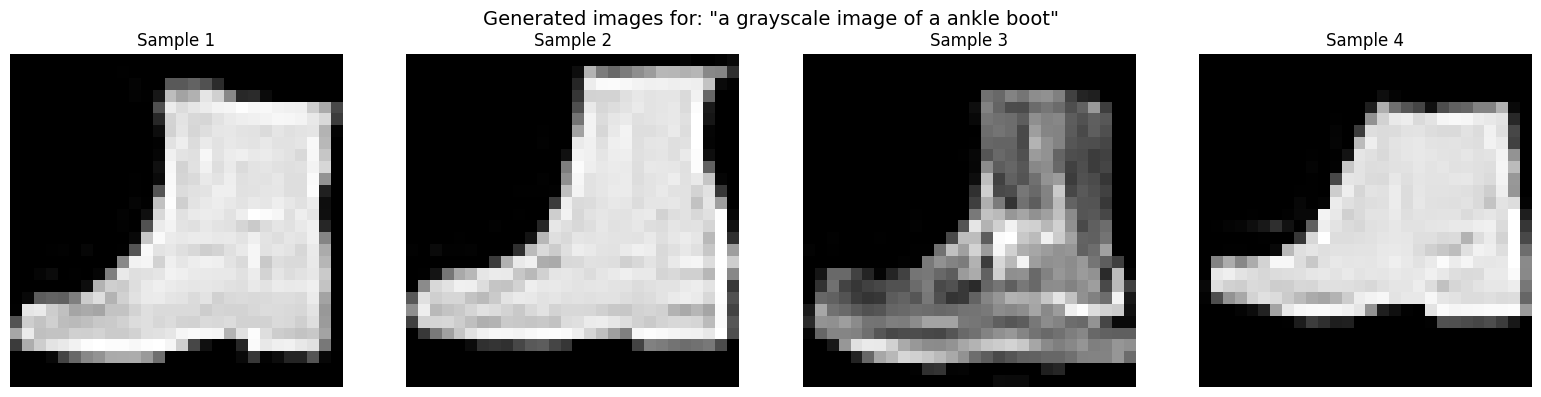

In [16]:
# Demo: Generate images from various fashion prompts

print("Interactive Text-to-Image Generation")
print("=" * 40)

# Get user input
custom_prompt = input("Enter your fashion prompt (e.g., 'A red dress', 'Black sneakers'): ").strip()

# Handle empty input
if not custom_prompt:
    custom_prompt = "A stylish shirt"
    print(f"No prompt entered, using default: '{custom_prompt}'")

# Ask for number of samples
try:
    num_samples = int(input("How many variations would you like? (1-8): "))
    if num_samples < 1 or num_samples > 8:
        num_samples = 4
        print(f"Invalid number, using default: {num_samples} samples")
except:
    num_samples = 4
    print(f"Invalid input, using default: {num_samples} samples")

print(f"\n Generating {num_samples} images for prompt: '{custom_prompt}'")

# Generate images
custom_images = text_to_image([custom_prompt], num_samples=num_samples)

# Display results
fig, axes = plt.subplots(1, num_samples, figsize=(16, 4))
if num_samples == 1:
    axes = [axes]

for i in range(num_samples):
    img = custom_images[i].cpu().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Sample {i+1}')
    axes[i].axis('off')

plt.suptitle(f'Generated images for: "{custom_prompt}"', fontsize=14)
plt.tight_layout()
plt.show()

# Optionally save the custom generation
save_custom = False  # Set to False if you don't want to save
if save_custom:
    os.makedirs('./demo_results', exist_ok=True)
    clean_prompt = custom_prompt.replace(" ", "_").replace("/", "_").lower()
    grid = make_grid(custom_images, nrow=num_samples, normalize=False, pad_value=1)
    save_image(grid, f'./demo_results/{clean_prompt}.png')
    print(f"Custom generation saved as '{clean_prompt}.png'")


 Evaluating Final Model on Test Set
Model: ./models/generator_190.pth
Test data: ./data/fashion_CLIP_test_caps.parquet
Batch size: 64

 Loading test data...
 Computing FID score...

 Evaluation Results:
FID Score: 13.21

 Real vs Generated Images Comparison:


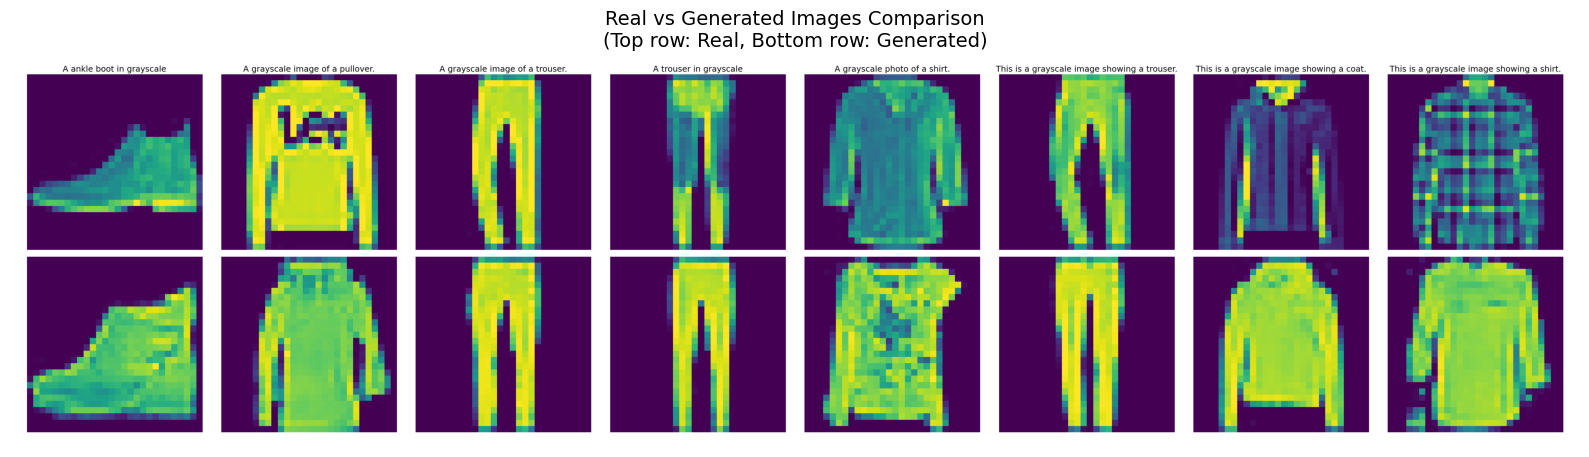

In [20]:
# Model Evaluation
print(" Evaluating Final Model on Test Set")
print("=" * 50)

import json
from torchmetrics.image.fid import FrechetInceptionDistance
from src.dataloader import get_fashion_dataloader
from PIL import Image

# Set up evaluation parameters
eval_parquet = "./data/fashion_CLIP_test_caps.parquet"
eval_img_dir = "./data"
eval_batch_size = 64
eval_latent_dim = 150
eval_embed_dim = 512
eval_ckpt_path = "./models/generator_190.pth"
eval_results_dir = "./demo_results"
os.makedirs(eval_results_dir, exist_ok=True)

print(f"Model: {eval_ckpt_path}")
print(f"Test data: {eval_parquet}")
print(f"Batch size: {eval_batch_size}")
print()

# Get dataloader for evaluation
print(" Loading test data...")
eval_loader = get_fashion_dataloader(
    eval_parquet, eval_img_dir,
    batch_size=eval_batch_size, 
    train=False, 
    shuffle=False
)

# Initialize FID metric
fid_metric = FrechetInceptionDistance(normalize=True).to(device)
print(" Computing FID score...")

first_batch_saved = False
grid_path = os.path.join(eval_results_dir, "eval_real_fake.png")

with torch.no_grad():
    for real_imgs, embeds, captions in eval_loader:
        real_imgs = real_imgs.to(device)
        embeds = embeds.to(device)
        bs = real_imgs.size(0)
        
        # Generate fake images
        z = torch.randn(bs, eval_latent_dim, device=device)
        fake_imgs = generator(z, embeds)
        
        # Update FID metric
        real_batch = (real_imgs + 1) * 0.5
        if real_batch.size(1) == 1:
            real_batch = real_batch.repeat(1, 3, 1, 1)
        fid_metric.update(real_batch, real=True)
        
        fake_batch = (fake_imgs + 1) * 0.5
        if fake_batch.size(1) == 1:
            fake_batch = fake_batch.repeat(1, 3, 1, 1)
        fid_metric.update(fake_batch, real=False)
        
        # Save comparison grid for first batch
        if not first_batch_saved:
            save_real_fake_grid(real_imgs, fake_imgs, captions, 
                               grid_path, n=8, start_idx=0)
            first_batch_saved = True

# Compute FID score
fid_value = fid_metric.compute().item()

# Display results
print(f"\n Evaluation Results:")
print(f"{'='*30}")
print(f"FID Score: {fid_value:.2f}")
print(f"{'='*30}")

# Display the real vs fake comparison
print(f"\n Real vs Generated Images Comparison:")
if os.path.exists(grid_path):
    img = Image.open(grid_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Real vs Generated Images Comparison\n(Top row: Real, Bottom row: Generated)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Comparison image not found")

# Save FID result
save_result = False
if save_result:
    eval_results = {"fid": fid_value}
    with open(os.path.join(eval_results_dir, "fid_result.json"), "w") as f:
        json.dump(eval_results, f, indent=2)
    print(f"\n FID result saved to: {eval_results_dir}/fid_result.json")